
=== Model: Logistic Regression ===

Confusion Matrix:
[[167  17]
 [ 29  87]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.91      0.88       184
           1       0.84      0.75      0.79       116

    accuracy                           0.85       300
   macro avg       0.84      0.83      0.83       300
weighted avg       0.85      0.85      0.84       300

ROC-AUC Score: 0.83


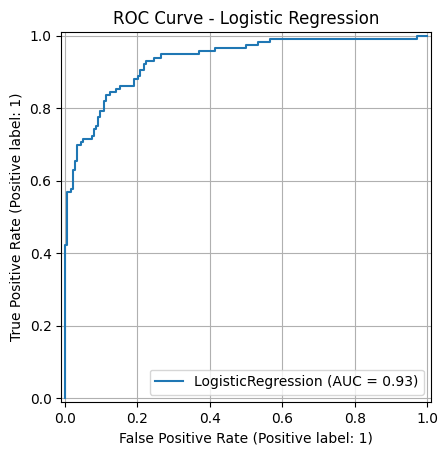


=== Model: Decision Tree ===

Confusion Matrix:
[[166  18]
 [ 22  94]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.90      0.89       184
           1       0.84      0.81      0.82       116

    accuracy                           0.87       300
   macro avg       0.86      0.86      0.86       300
weighted avg       0.87      0.87      0.87       300

ROC-AUC Score: 0.86


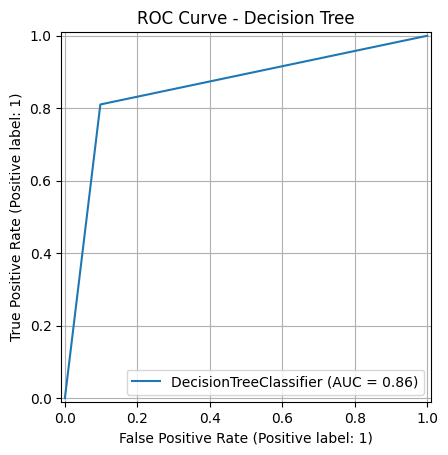


=== Model: Random Forest ===

Confusion Matrix:
[[176   8]
 [ 25  91]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.96      0.91       184
           1       0.92      0.78      0.85       116

    accuracy                           0.89       300
   macro avg       0.90      0.87      0.88       300
weighted avg       0.89      0.89      0.89       300

ROC-AUC Score: 0.87


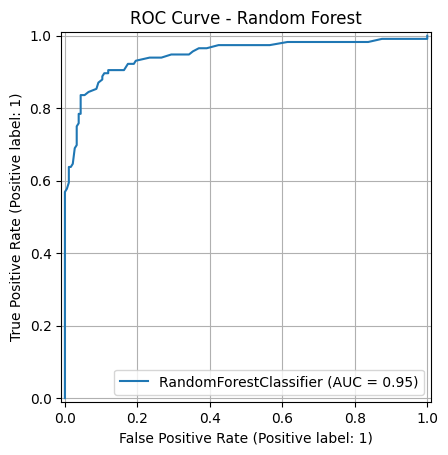


=== Model: KNN ===

Confusion Matrix:
[[170  14]
 [ 51  65]]

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.92      0.84       184
           1       0.82      0.56      0.67       116

    accuracy                           0.78       300
   macro avg       0.80      0.74      0.75       300
weighted avg       0.79      0.78      0.77       300

ROC-AUC Score: 0.74


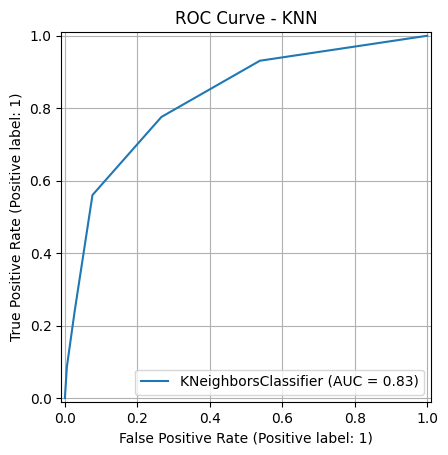


=== Model: ANN ===

Confusion Matrix:
[[158  26]
 [ 27  89]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.86      0.86       184
           1       0.77      0.77      0.77       116

    accuracy                           0.82       300
   macro avg       0.81      0.81      0.81       300
weighted avg       0.82      0.82      0.82       300

ROC-AUC Score: 0.81


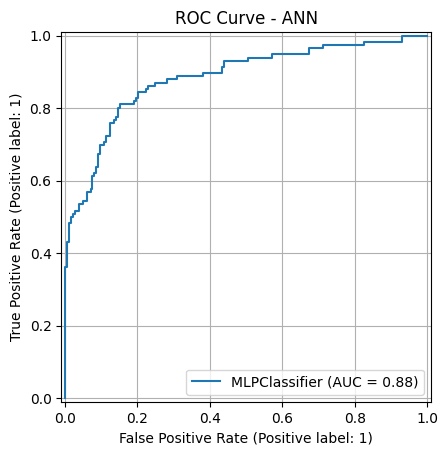


====== Real-Time Cancer Risk Prediction ======


Enter Age:  19
Enter Gender:  1
Enter BMI:  20
Enter Smoking:  1
Enter GeneticRisk:  0
Enter PhysicalActivity:  


Invalid input. Please enter numbers only!


Enter Age:  19
Enter Gender:  1
Enter BMI:  20
Enter Smoking:  1
Enter GeneticRisk:  0
Enter PhysicalActivity:  6
Enter AlcoholIntake:  1
Enter CancerHistory:  0
Enter DietQuality:  2
Enter RadiationExposure:  0
Enter OccupationRisk:  0
Enter StressLevel:  2
Enter HormonalTherapy:  0
Enter PreExistingConditions:  0
Enter EnvironmentalExposure:  1
Enter SleepDuration:  4.5
Enter AirPollutionExposure:  1
Enter ExerciseType:  1
Enter ProcessedMeatIntake:  1
Enter SugarConsumption:  50
Enter Region:  1
Enter EducationLevel:  1



🚨 Prediction: Low Risk


Was this prediction correct? (yes/no):  No


❌ Feedback not recorded.



Do you want to predict for another person? (yes/no):  no


PermissionError: [Errno 13] Permission denied: 'C:/Users/arakk/OneDrive/Documents/Lab Sheet/Machine Learning/Project/Enhanced_Cancer_Data_Updated1.csv'

In [3]:
# Cancer Risk Prediction with Feedback and Plots
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
# 1. Load Dataset
try:
    df = pd.read_csv("C:/Users/arakk/OneDrive/Documents/Lab Sheet/Machine Learning/Project/Enhanced_Cancer_Data_Updated1.csv")
except:
    raise FileNotFoundError("Dataset not found! Please upload 'Enhanced_Cancer_Data_Updated.csv'.")
# 2. Split Features and Target
X = df.drop("Diagnosis", axis=1)
y = df["Diagnosis"]

# 3. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# 5. Define Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier(),
    "ANN": MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=1000)
}
# 6. Train and Evaluate Models
for name, model in models.items():
    print(f"\n=== Model: {name} ===")
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred):.2f}")

    RocCurveDisplay.from_estimator(model, X_test_scaled, y_test)
    plt.title(f"ROC Curve - {name}")
    plt.grid(True)
    plt.show()
# 7. Use Random Forest for Real-Time Prediction
selected_model = RandomForestClassifier()
selected_model.fit(X_train_scaled, y_train)
# 8. Real-Time User Interaction
print("\n====== Real-Time Cancer Risk Prediction ======")
while True:
    try:
        user_data = {}
        for feature in X.columns:
            value = float(input(f"Enter {feature}: "))
            user_data[feature] = value
        user_df = pd.DataFrame([user_data])
    except:
        print("Invalid input. Please enter numbers only!")
        continue

    user_scaled = scaler.transform(user_df)
    prediction = selected_model.predict(user_scaled)[0]
    prediction_label = "High Risk" if prediction == 1 else "Low Risk"
    print(f"\n\U0001F6A8 Prediction: {prediction_label}")
    feedback = input("Was this prediction correct? (yes/no): ").strip().lower()
    if feedback == "yes":
        user_df["Diagnosis"] = prediction
        df = pd.concat([df, user_df], ignore_index=True)
        print("\u2705 Feedback recorded. Updating model...")

        X = df.drop("Diagnosis", axis=1)
        y = df["Diagnosis"]
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        selected_model.fit(X_train_scaled, y_train)
    else:
        print("\u274C Feedback not recorded.")

    cont = input("\nDo you want to predict for another person? (yes/no): ").strip().lower()
    if cont != "yes":
        break
# . Save Updated Dataset
df.to_csv("C:/Users/arakk/OneDrive/Documents/Lab Sheet/Machine Learning/Project/Enhanced_Cancer_Data_Updated1.csv", index=False)
print("\n\U0001F4C1 Dataset updated and saved successfully as 'Enhanced_Cancer_Data_Updated1.csv'!")

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# 1. Load Dataset
try:
    df = pd.read_csv("C:/Users/arakk/OneDrive/Documents/Lab Sheet/Machine Learning/Project/Enhanced_Cancer_Data_Updated1.csv")
except:
    raise FileNotFoundError("Dataset not found! Please upload 'Enhanced_Cancer_Data_Updated1.csv'.")

# 2. Split Features and Target
X = df.drop("Diagnosis", axis=1)
y = df["Diagnosis"]

# 3. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Define Random Forest and XGBoost
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# Train tree-based models
rf_model.fit(X_train_scaled, y_train)
xgb_model.fit(X_train_scaled, y_train)

# 6. Define and Train Neural Network
dnn_model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')  # Binary output
])

dnn_model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

dnn_model.fit(X_train_scaled, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=0)

# 7. Combine Predictions (Soft Voting)
def hybrid_predict(X_scaled):
    rf_probs = rf_model.predict_proba(X_scaled)[:, 1]
    xgb_probs = xgb_model.predict_proba(X_scaled)[:, 1]
    dnn_probs = dnn_model.predict(X_scaled).flatten()

    # Weighted average of probabilities
    combined_probs = (0.3 * rf_probs) + (0.3 * xgb_probs) + (0.4 * dnn_probs)
    return (combined_probs > 0.5).astype(int)  # Threshold at 0.5

# Evaluate Hybrid Model
y_pred = hybrid_predict(X_test_scaled)
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
print("\n=== Hybrid Ensemble Model Evaluation ===")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred):.2f}")

# 8. Real-Time User Interaction
print("\n====== Real-Time Cancer Risk Prediction ======")
while True:
    try:
        user_data = {}
        for feature in X.columns:
            value = float(input(f"Enter {feature}: "))
            user_data[feature] = value
        user_df = pd.DataFrame([user_data])
    except:
        print("Invalid input. Please enter numbers only!")
        continue

    user_scaled = scaler.transform(user_df)
    prediction = hybrid_predict(user_scaled)[0]
    prediction_label = "High Risk" if prediction == 1 else "Low Risk"
    print(f"\n\U0001F6A8 Prediction: {prediction_label}")

    # Ask for actual diagnosis
    actual_diagnosis = input("What is the actual diagnosis? (0 = No Cancer, 1 = Cancer Diagnosed): ").strip()
    while actual_diagnosis not in ['0', '1']:
        print("Invalid input. Please enter 0 or 1.")
        actual_diagnosis = input("What is the actual diagnosis? (0 = No Cancer, 1 = Cancer Diagnosed): ").strip()

    # Update dataset with correct diagnosis
    user_df["Diagnosis"] = int(actual_diagnosis)
    df = pd.concat([df, user_df], ignore_index=True)
    print("\u2705 Actual diagnosis recorded. Updating models...")

    # Retrain models with updated data
    X = df.drop("Diagnosis", axis=1)
    y = df["Diagnosis"]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    rf_model.fit(X_train_scaled, y_train)
    xgb_model.fit(X_train_scaled, y_train)
    dnn_model.fit(X_train_scaled, y_train, epochs=30, batch_size=32, verbose=0)

    cont = input("\nDo you want to predict for another person? (yes/no): ").strip().lower()
    if cont != "yes":
        break

# Save Updated Dataset
df.to_csv("C:/Users/arakk/OneDrive/Documents/Lab Sheet/Machine Learning/Project/Enhanced_Cancer_Data_Updated1.csv", index=False)
print("\n\U0001F4C1 Dataset updated and saved successfully as 'Enhanced_Cancer_Data_Updated1.csv'!")
